# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

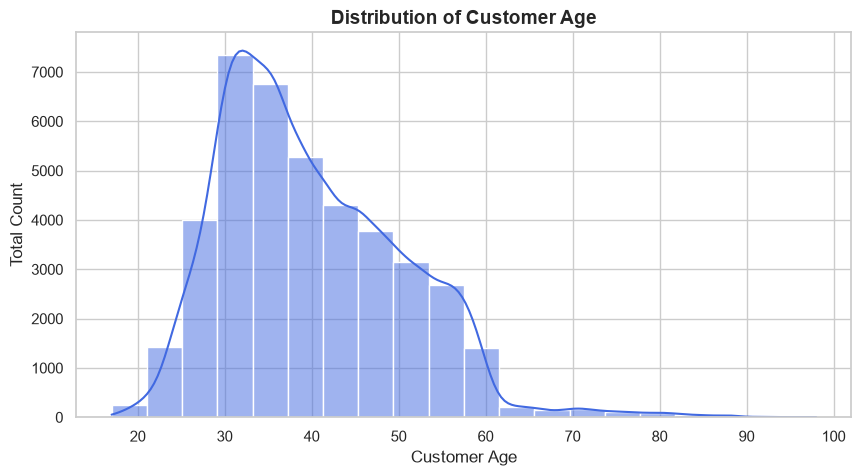

In [2]:
# Age distribution
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='age',bins=20,kde=True,color='royalblue')
plt.title('Distribution of Customer Age', fontsize=14,fontweight='bold')
plt.xlabel('Customer Age',fontsize=12)
plt.ylabel('Total Count',fontsize=12)
plt.show()


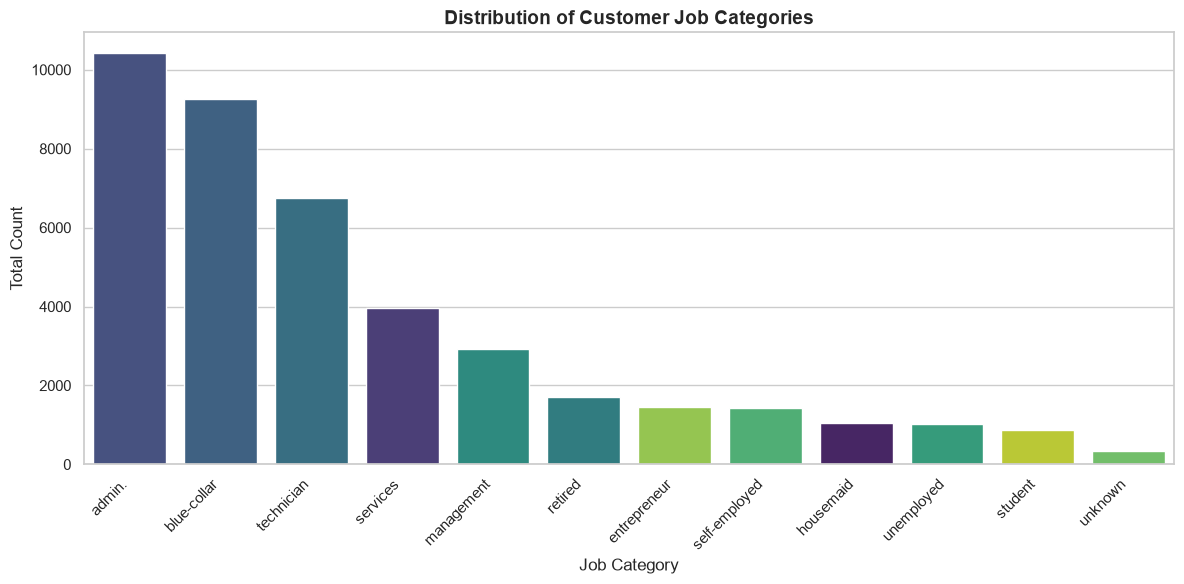

In [3]:
# Job distribution
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='job',
    hue='job',
    order=df['job'].value_counts().index,
    palette='viridis',
    legend=False
    )
plt.title('Distribution of Customer Job Categories', fontsize=14,fontweight='bold')
plt.xlabel('Job Category',fontsize=12)
plt.ylabel('Total Count',fontsize=12)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

## Balance & Deposit Trends

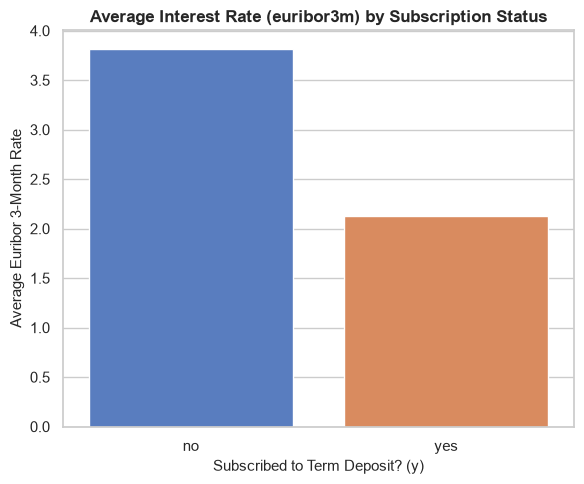

In [4]:
# Average balance by deposit subscription
# Calculate the average interest rate for each subscription status
trend_data = df.groupby('y')['euribor3m'].mean().reset_index()

# Set up the visualization plot
plt.figure(figsize=(6, 5))
sns.barplot(
    data=trend_data, 
    x='y', 
    y='euribor3m', 
    hue='y', 
    palette='muted', 
    legend=False
)

# Add titles and labels
plt.title('Average Interest Rate (euribor3m) by Subscription Status', fontsize=12, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (y)', fontsize=11)
plt.ylabel('Average Euribor 3-Month Rate', fontsize=11)

# Render the plot cleanly
plt.tight_layout()
plt.show()


## Campaign Effectiveness

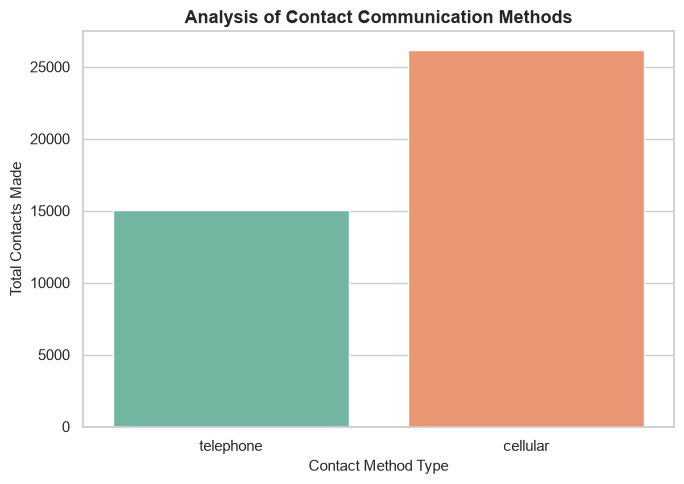

In [5]:
# Contact method analysis
# Set the figure size for the contact chart
plt.figure(figsize=(7, 5))

# Create a clean distribution plot for communication types
sns.countplot(
    data=df, 
    x='contact', 
    hue='contact', 
    palette='Set2', 
    legend=False
)

# Add clear professional labels and title
plt.title('Analysis of Contact Communication Methods', fontsize=13, fontweight='bold')
plt.xlabel('Contact Method Type', fontsize=11)
plt.ylabel('Total Contacts Made', fontsize=11)

# Render the layout cleanly
plt.tight_layout()
plt.show()



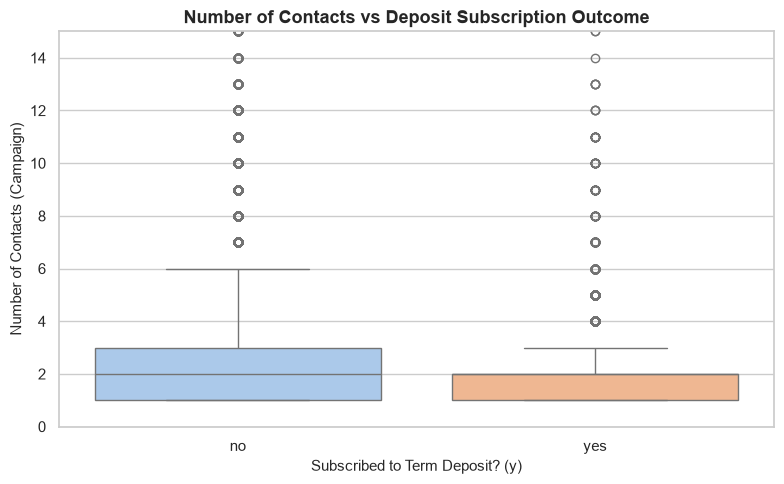

In [6]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8, 5))

# Boxplot to compare contact count across outcomes
sns.boxplot(
    data=df, 
    x='y', 
    y='campaign', 
    hue='y', 
    palette='pastel', 
    legend=False
)

# Limiting y-axis to see the main distribution clearly without outliers distorting the view
plt.ylim(0, 15)

plt.title('Number of Contacts vs Deposit Subscription Outcome', fontsize=13, fontweight='bold')
plt.xlabel('Subscribed to Term Deposit? (y)', fontsize=11)
plt.ylabel('Number of Contacts (Campaign)', fontsize=11)

plt.tight_layout()
plt.show()



## Correlation Heatmap

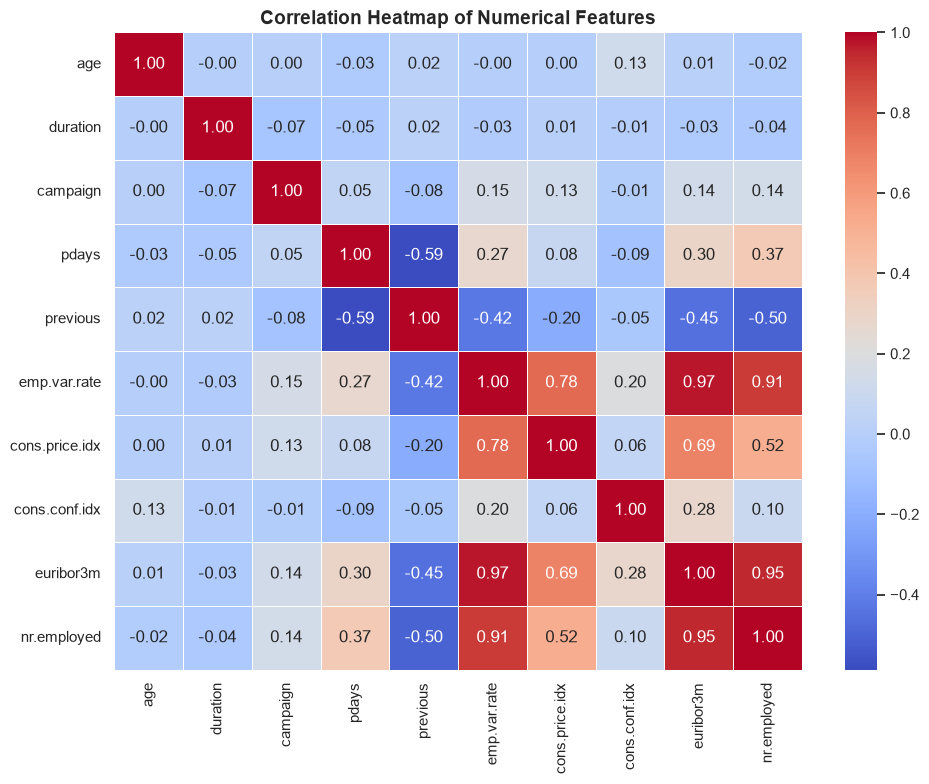

In [7]:
# Correlation of numerical variables
plt.figure(figsize=(10, 8))

# Select only numeric data fields for correlation matrix calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Create a clean heatmap visualization
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## Predictive Modeling (Logistic Regression)

In [8]:


# Encode categorical variables
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Convert 'yes'/'no' target variable to 1/0
df_model = df.copy()
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

# Select feature columns (excluding target variable)
X = df_model.drop(columns=['y'])
y = df_model['y']

# One-hot encode all text categorical columns safely
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Data successfully prepared and split!")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


# Predictions
# Initialize and train the Logistic Regression model
# max_iter is increased to ensure full convergence during training
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred = model.predict(X_test)

# Display model evaluation performance
print(" Model Performance Report")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))



Data successfully prepared and split!
Training set size: 32950 rows
Testing set size: 8238 rows
 Model Performance Report
Accuracy Score: 0.9111

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



c:\Users\divya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


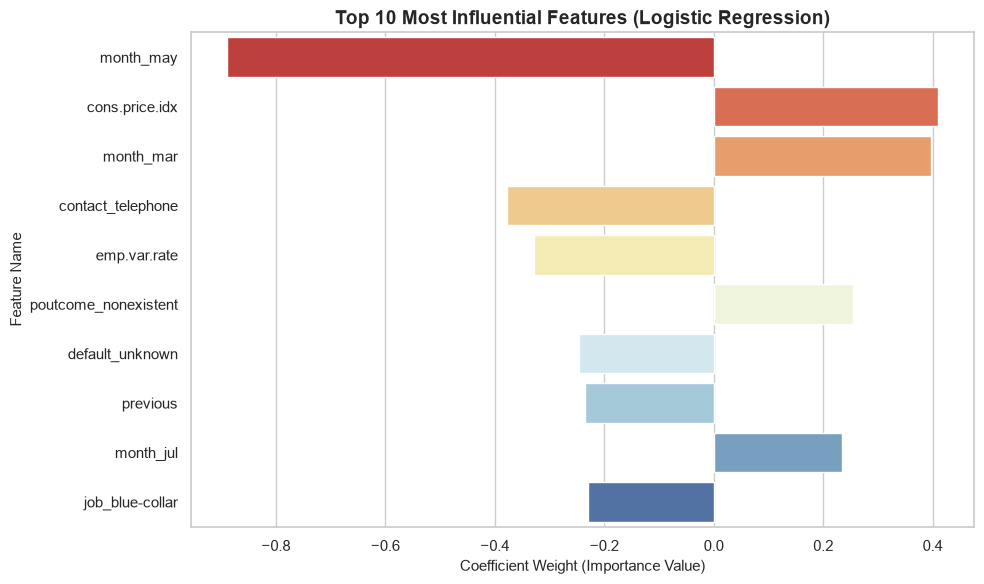

In [9]:
# Feature importance
# Extract model coefficients as feature importances
coefficients = model.coef_[0]
feature_names = X_encoded.columns

# Create a clean DataFrame sorted by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values(by='Importance', key=abs, ascending=False).head(10) # Showing top 10 most impactful features

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df, 
    y='Feature', 
    x='Importance', 
    hue='Feature',
    palette='RdYlBu',
    legend=False
)

plt.title('Top 10 Most Influential Features (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Weight (Importance Value)', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)

plt.tight_layout()
plt.show()



## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.